# 01 — Análise Exploratória de Dados

Base: [`WineQT.csv`](../data/raw/WineQT.csv) — 1.143 amostras de vinho tinto, cada uma com 11
variáveis físico-químicas e uma nota de qualidade (`quality`, de 3 a 8) atribuída por
especialistas.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append(str(Path("..").resolve()))
from src.config import (
    RANDOM_STATE, DATA_RAW, DATA_PROCESSED, RESULTS, FIGURES, METRICS, MODELS,
    RAW_FILE, PROCESSED_FILE, ID_COL, TARGET, TARGET_BIN, QUALITY_THRESHOLD,
    TEST_SIZE, CV_FOLDS,
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

In [2]:
df = pd.read_csv(RAW_FILE)
df = df.drop(columns=[ID_COL])
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 1. Visão geral

In [3]:
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
df.info()

Linhas: 1143 | Colunas: 12
<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [4]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311,1.748,4.600,7.100,7.900,9.100,15.900
volatile acidity,1143.0,0.531,0.180,0.120,0.392,0.520,0.640,1.580
citric acid,1143.0,0.268,0.197,0.000,0.090,0.250,0.420,1.000
residual sugar,1143.0,2.532,1.356,0.900,1.900,2.200,2.600,15.500
chlorides,1143.0,0.087,0.047,0.012,0.070,0.079,0.090,0.611
free sulfur dioxide,1143.0,15.615,10.250,1.000,7.000,13.000,21.000,68.000
total sulfur dioxide,1143.0,45.915,32.782,6.000,21.000,37.000,61.000,289.000
density,1143.0,0.997,0.002,0.990,0.996,0.997,0.998,1.004
pH,1143.0,3.311,0.157,2.740,3.205,3.310,3.400,4.010
sulphates,1143.0,0.658,0.170,0.330,0.550,0.620,0.730,2.000


**Interpretação:** o dataset tem 1.143 linhas e 12 colunas (11 variáveis
físico-químicas + `quality`), todas numéricas, sem nenhum valor nulo. As escalas são
muito diferentes entre si — `total sulfur dioxide` varia de ~6 a 289 mg/L, enquanto
`pH` fica entre 2,74 e 4,01 e `density` mal sai de 0,99–1,00 — o que confirma a
necessidade de padronizar as variáveis antes de usar um modelo linear ou baseado em
distância (Regressão Logística), sob risco de as colunas em escala maior dominarem o
ajuste. Modelos baseados em árvore (Random Forest, Gradient Boosting) não sofrem com
isso, mas padronizar não os prejudica.

## 2. Distribuição das variáveis

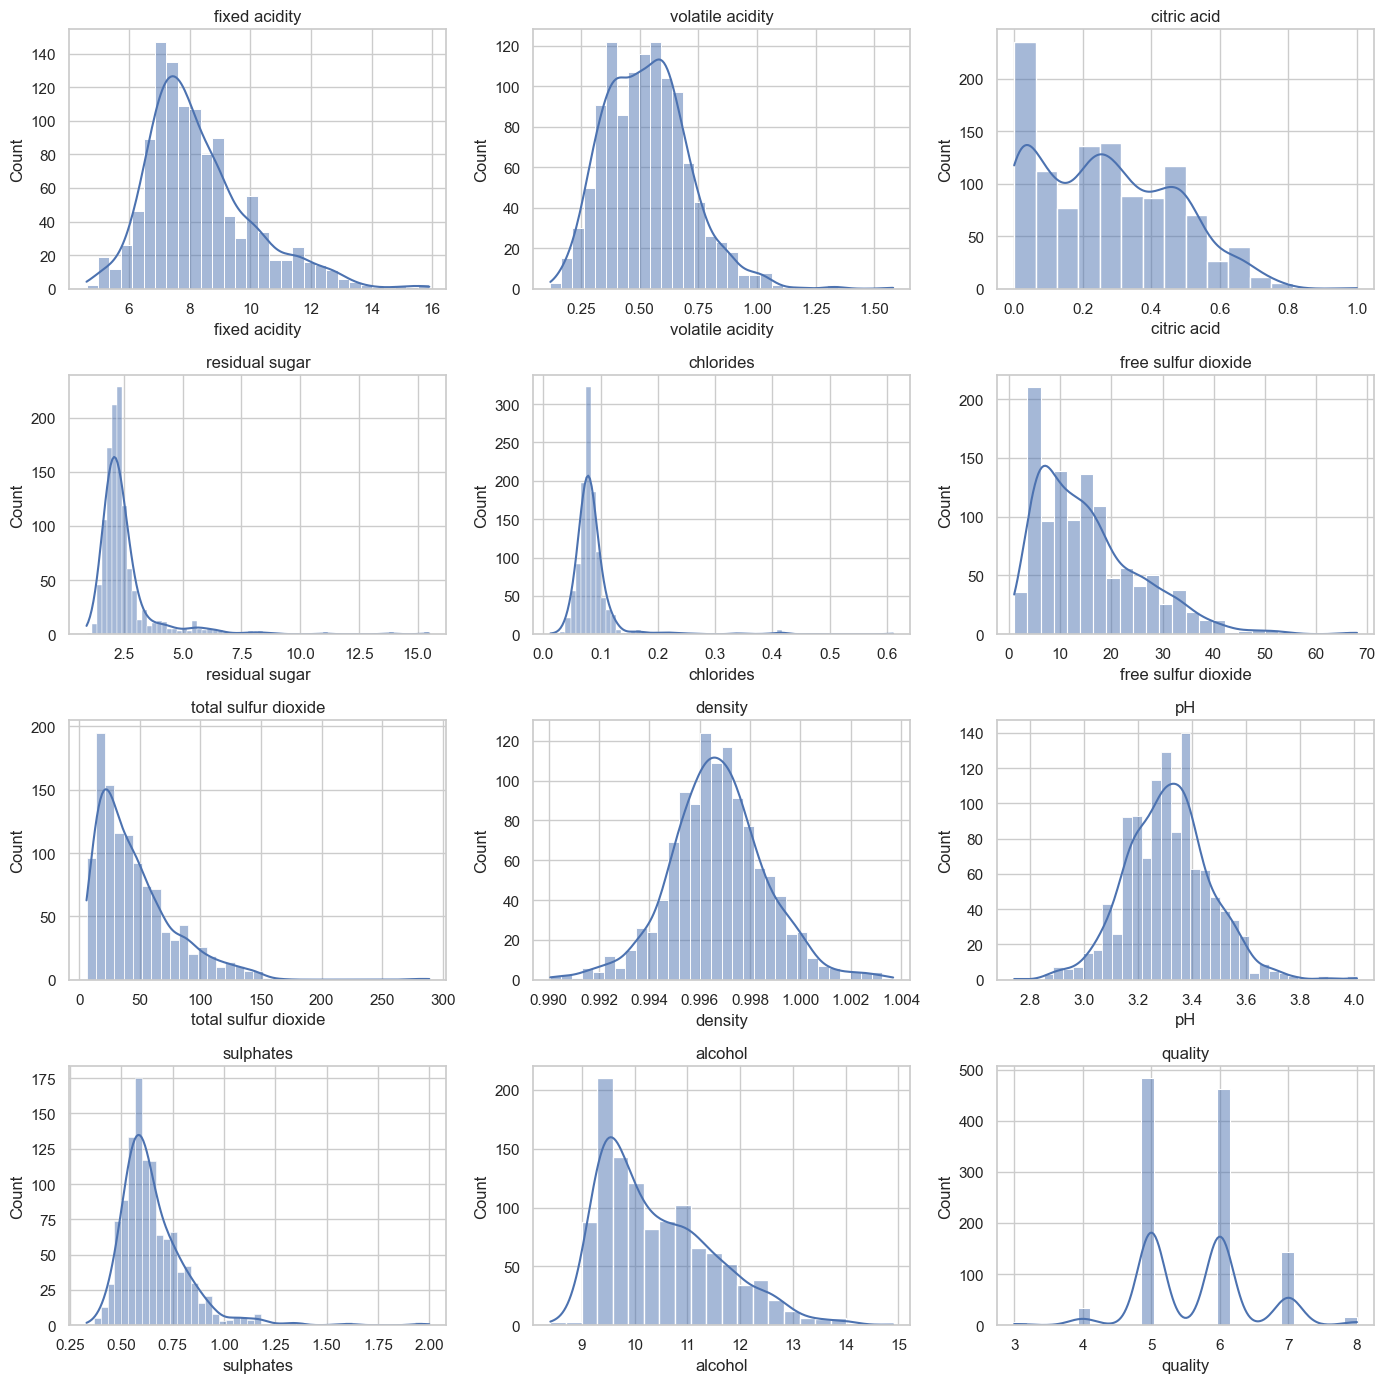

In [5]:
fig, axes = plt.subplots(4, 3, figsize=(14, 14))
for ax, col in zip(axes.ravel(), df.columns):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
fig.tight_layout()
FIGURES.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES / "01_distribuicoes.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretação:** a maioria das variáveis é assimétrica à direita, algumas de forma
acentuada — `chlorides` (assimetria ≈ 6,0) e `residual sugar` (≈ 4,4) têm uma cauda longa
de valores altos sobre uma massa concentrada em valores baixos; `sulphates` (≈ 2,5),
`total sulfur dioxide` (≈ 1,7) e `free sulfur dioxide` (≈ 1,2) seguem o mesmo padrão,
mais moderado. `density` (≈ 0,10) e `pH` (≈ 0,22) são as únicas praticamente simétricas,
parecidas com uma normal. A variável alvo `quality` está concentrada em 5 e 6 (juntas,
82,7% das amostras), com poucas amostras nos extremos (nota 3: 0,52%; nota 8: 1,40%) —
o primeiro sinal de que a classificação binária vai herdar desbalanceamento
(retomado na seção 5).

## 3. Correlações

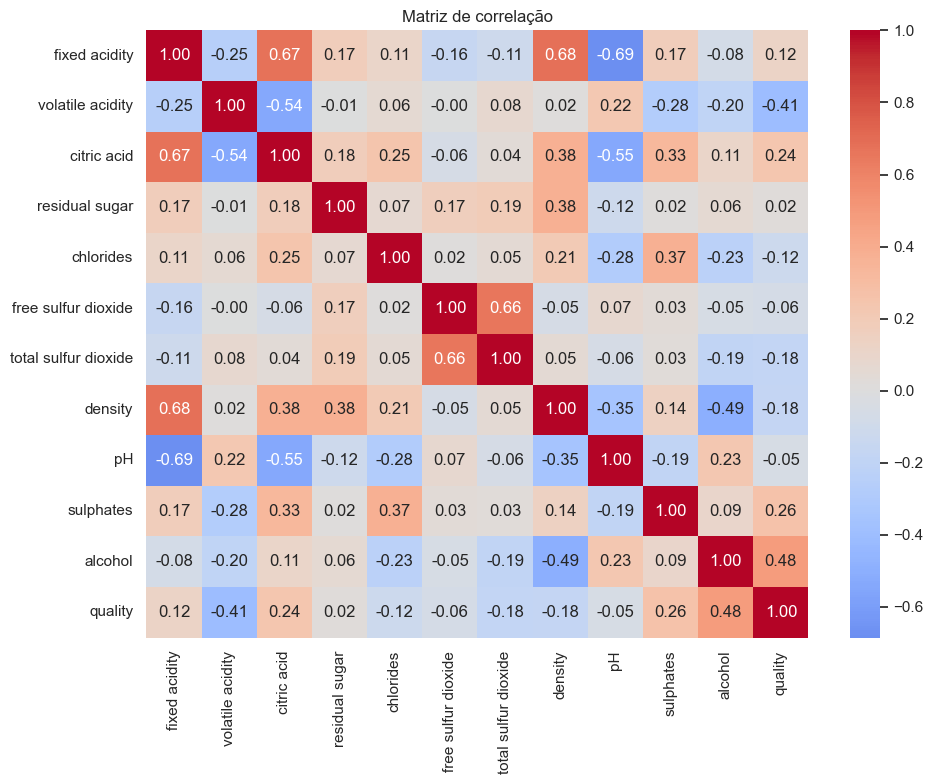

In [6]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlação")
fig.tight_layout()
fig.savefig(FIGURES / "02_correlacoes.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
corr[TARGET].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64

**Interpretação:** com a nota de qualidade, `alcohol` tem a correlação positiva mais
forte (r = 0,49), seguido de `sulphates` (0,26) e `citric acid` (0,24) — vinhos com mais
teor alcoólico, mais sulfatos (conservante/antioxidante) e mais ácido cítrico (frescor)
tendem a nota mais alta. Do lado negativo, `volatile acidity` se destaca (r = −0,41):
é o ácido acético, responsável pelo gosto de vinagre em excesso, então quanto maior,
pior a nota — coerente com a literatura enológica. `total sulfur dioxide` (−0,18) e
`density` (−0,17) têm correlação negativa mais fraca.

Também há multicolinearidade relevante **entre variáveis explicativas**, não com o alvo:
`fixed acidity` correlaciona com `pH` (−0,69), `density` (0,68) e `citric acid` (0,67); e
`free sulfur dioxide` com `total sulfur dioxide` (0,66). Isso é esperado quimicamente —
pH é definido pela concentração de ácidos, densidade é afetada por açúcar/álcool/ácidos,
e SO₂ livre é por definição uma fração do SO₂ total. Nenhuma variável foi descartada por
isso: modelos de árvore lidam bem com colinearidade, e o modelo linear usa regularização
L2 (padrão do `LogisticRegression`) em vez de remoção manual de colunas.

## 4. Outliers

In [8]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < lo) | (s > hi)).sum())

outliers = pd.DataFrame({
    "outliers": {c: iqr_outliers(df[c]) for c in df.columns if c != TARGET},
})
outliers["pct"] = (outliers["outliers"] / len(df) * 100).round(2)
outliers.sort_values("outliers", ascending=False)

,outliers,pct
residual sugar,110,9.62
chlorides,77,6.74
fixed acidity,44,3.85
sulphates,43,3.76
total sulfur dioxide,40,3.50
density,36,3.15
pH,20,1.75
free sulfur dioxide,18,1.57
volatile acidity,14,1.22
alcohol,12,1.05


C:\Users\Felipe\AppData\Local\Temp\ipykernel_3840\3129681247.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


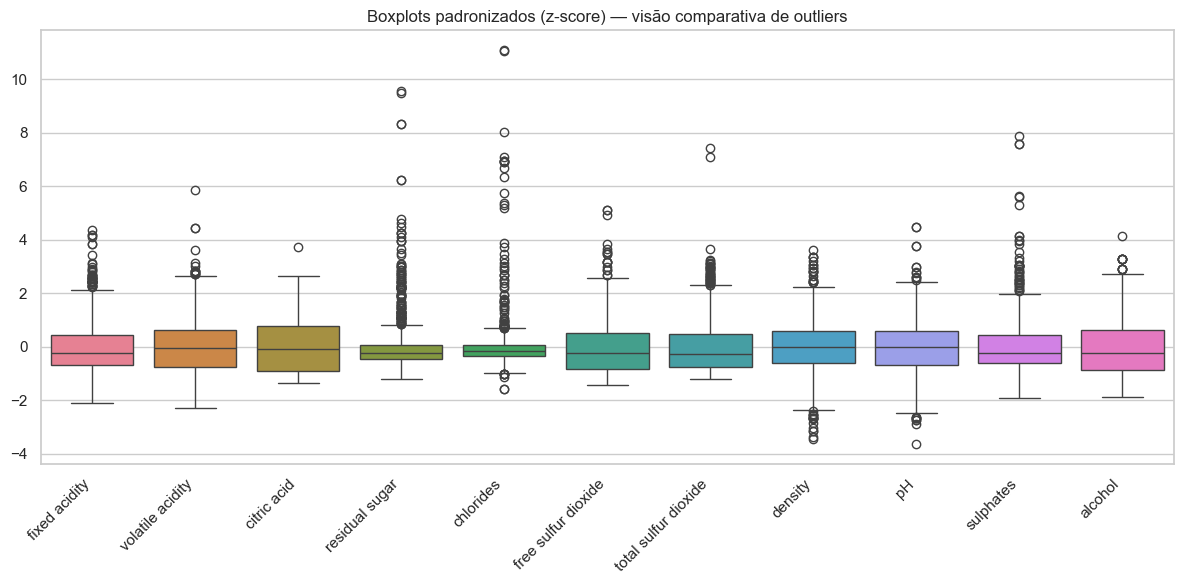

In [9]:
from sklearn.preprocessing import StandardScaler

num_cols = [c for c in df.columns if c != TARGET]
scaled = pd.DataFrame(StandardScaler().fit_transform(df[num_cols]), columns=num_cols)
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=scaled, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_title("Boxplots padronizados (z-score) — visão comparativa de outliers")
fig.tight_layout()
fig.savefig(FIGURES / "03_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretação:** pelo critério de 1,5×IQR, `residual sugar` (9,62%) e `chlorides`
(6,74%) têm a maior proporção de outliers, seguidas por `fixed acidity` (3,85%),
`sulphates` (3,76%), `total sulfur dioxide` (3,50%) e `density` (3,15%); as demais ficam
abaixo de 2%. Esses valores são fisicamente plausíveis para vinho (alguns lotes mais
doces ou mais salinos por natureza da uva/processo), não indícios de erro de digitação
ou de sensor — por isso **nenhuma linha é removida**. A estratégia adotada é: usar
`StandardScaler` (menos sensível a extremos que normalização min-max) para o modelo
linear, e contar com a robustez natural de Random Forest e Gradient Boosting a outliers
para os demais modelos.

## 5. Balanceamento de classes

In [10]:
df[TARGET].value_counts(normalize=True).sort_index().round(4) * 100

quality
3     0.52
4     2.89
5    42.26
6    40.42
7    12.51
8     1.40
Name: proportion, dtype: float64

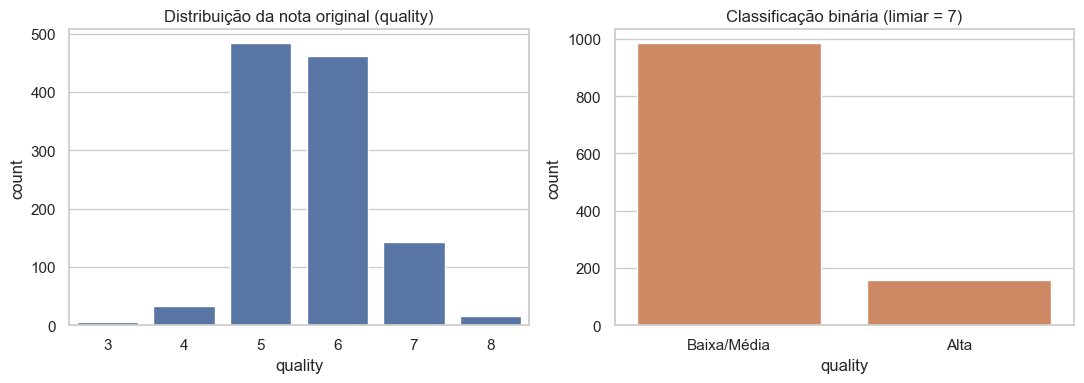

quality
Baixa/Média    86.09
Alta           13.91
Name: proportion, dtype: float64

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x=TARGET, data=df, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribuição da nota original (quality)")

preview_bin = (df[TARGET] >= QUALITY_THRESHOLD).map({True: "Alta", False: "Baixa/Média"})
sns.countplot(x=preview_bin, ax=axes[1], color="#DD8452",
              order=["Baixa/Média", "Alta"])
axes[1].set_title(f"Classificação binária (limiar = {QUALITY_THRESHOLD})")
fig.tight_layout()
fig.savefig(FIGURES / "04_balanceamento.png", dpi=150, bbox_inches="tight")
plt.show()

preview_bin.value_counts(normalize=True).round(4) * 100

**Interpretação:** com o limiar `quality >= 7` para alta qualidade, a classe positiva
corresponde a **13,91%** das amostras (159 de 1.143), contra **86,09%** de baixa/média —
proporção de aproximadamente 6,2 vinhos comuns para cada vinho de alta qualidade. Esse
desbalanceamento tem consequência direta sobre a escolha das métricas e sobre o desenho
da modelagem: a acurácia isolada é insuficiente como critério de avaliação, uma vez que
um classificador que atribuísse a todos os casos a classe majoritária alcançaria 86% de
acerto sem identificar corretamente nenhum vinho de alta qualidade. Por essa razão,
priorizam-se F1, revocação, precisão e AUC-ROC (retomados no notebook 04). O
desbalanceamento justifica igualmente o uso de `stratify=y` no particionamento e na
validação cruzada, bem como de `class_weight="balanced"` nos modelos que suportam esse
parâmetro (notebook 03), de modo que a classe minoritária não seja desconsiderada
durante o treinamento.

## 6. Síntese da EDA

O dataset é limpo (sem nulos, sem tipos incorretos) e as variáveis mais associadas à
qualidade alta são teor alcoólico, sulfatos e ácido cítrico (positivamente) e acidez
volátil (negativamente) — um padrão consistente com o que se sabe sobre a química do
vinho: mais álcool e menos "gosto de vinagre" tendem a agradar mais o paladar dos
avaliadores. As variáveis explicativas têm colinearidade natural entre si (acidez,
pH e densidade se movem juntas), mas isso não compromete a modelagem escolhida. Os
outliers encontrados são plausíveis e foram mantidos. O ponto mais importante para as
próximas etapas é o desbalanceamento de classes (~14% de vinhos de alta qualidade):
ele define a métrica prioritária (F1/recall/AUC, não acurácia), a necessidade de split
estratificado e o uso de pesos balanceados nos modelos — decisões que carregam a
partir daqui até a avaliação final.